# 🎬 Multilabel Movie Genre Classification
### Based on: *Unal et al. (2023) — Multilabel Genre Prediction Using Deep-Learning Frameworks*

| Setting | Value |
|---|---|
| **Architectures** | VGG16, ResNet50, DenseNet121, MobileNet, ConvNeXt-Tiny |
| **Head** | BatchNorm1d → Dropout(p=0.5) → Linear(in_features, K) (Simplified Linear Probe) |
| **Loss** | BCEWithLogitsLoss + pos_weight (class imbalance) |
| **Threshold τ** | 0.5 |
| **Top-K** | Top-4 genres per poster |
| **Primary metric** | Hamming Loss |
| **Dataset** | 300 movie posters — 250 train / 50 test, genre.xlsx |

## Step 1 — Install & Import

In [32]:
!pip install openpyxl scikit-learn -q

import os, copy, warnings
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (f1_score, precision_score,
                              recall_score, roc_auc_score)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Device : cuda
GPU    : Tesla T4


## Step 2 — Mount Drive & Global Config

In [33]:
from google.colab import drive
drive.mount('/content/drive')

# ── CONFIGURE YOUR PATHS HERE ─────────────────────────────────────────────────
BASE_PATH  = '/content/drive/My Drive/cvis/'
EXCEL_PATH = BASE_PATH + 'genre.xlsx'
TRAIN_DIR  = BASE_PATH + 'images/train/'   # 1.jpg  – 250.jpg
TEST_DIR   = BASE_PATH + 'images/test/'    # 251.jpg – 300.jpg
SAVE_DIR   = BASE_PATH + 'saved_models/'
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Hyperparameters (Unal et al. 2023 defaults) ───────────────────────────────
IMG_SIZE   = 256      # Paper: all models use 256×256
BATCH_SIZE = 32       # Paper: mini-batch = 32
NUM_EPOCHS = 50       # Customize to 50 epochs because smaller datasize
LR         = 1e-3     # Paper: Adam lr = 0.001
LR_FT      = 1e-5     # Fine-tuning lr (lower)
THRESHOLD  = 0.5      # Convention: τ = 0.5
TOP_K      = 4        # Custom: show top-4 genres

print('Paths OK:', os.path.exists(EXCEL_PATH),
      os.path.exists(TRAIN_DIR), os.path.exists(TEST_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths OK: True True True


## Step 3 — Load Dataset

In [34]:
df = pd.read_excel(EXCEL_PATH)
print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
df.head()

Shape   : (300, 16)
Columns : ['filename', 'title', 'action', 'adventure', 'animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']


,filename,title,action,adventure,animation,comedy,crime,drama,family,fantasy,horror,musical,mystery,romance,scifi,thriller
0,1.jpg,Jessica Jones,1,0,0,0,1,1,0,0,0,0,0,0,1,1
1,2.jpg,Squid Game 2,1,0,0,1,1,1,0,0,0,0,0,0,0,1
2,3.jpg,Hey Arnold,0,0,1,1,0,0,1,0,0,0,0,0,0,0
3,4.jpg,Unstopabble,1,0,0,1,1,0,0,0,0,0,0,0,0,1
4,5.jpg,Superman & Lois,1,1,0,0,0,1,0,0,0,0,0,0,1,0


Genres (14): ['action', 'adventure', 'animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
Train: 250  |  Test: 50


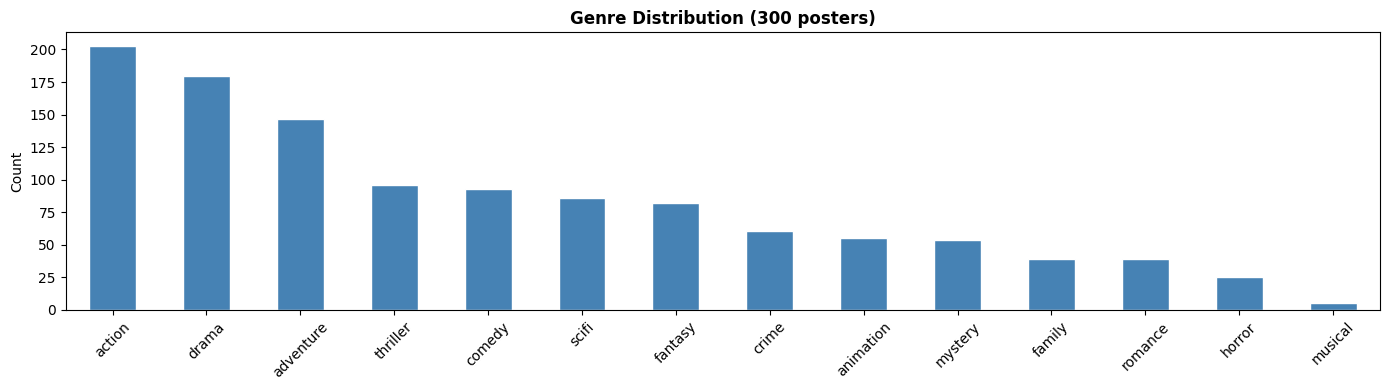

In [35]:
GENRE_COLS  = list(df.columns[2:])     # All columns after first 2 metadata cols
NUM_CLASSES = len(GENRE_COLS)
print(f'Genres ({NUM_CLASSES}): {GENRE_COLS}')

df_train = df.iloc[:250].copy().reset_index(drop=True)
df_test  = df.iloc[250:300].copy().reset_index(drop=True)
print(f'Train: {len(df_train)}  |  Test: {len(df_test)}')

# Genre distribution
counts = df[GENRE_COLS].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 4))
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Genre Distribution (300 posters)', fontweight='bold')
ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## Step 4 — Hamming Loss & Metrics

Hamming Loss formula from Unal et al. 2023, Eq.(4):
$$\text{Hamming Loss} = \frac{\text{Number of incorrectly predicted labels}}{\text{Total number of labels}}$$

In [36]:
def hamming_loss_fn(y_true, y_pred):
    """
    Hamming Loss — lower is better, 0 is perfect.
    Eq.(4) from Unal et al. 2023.
    """
    return np.mean(y_true != y_pred)


def compute_all_metrics(y_true, y_pred_probs,
                        threshold=THRESHOLD, top_k=TOP_K):
    """
    Returns full metrics dict using both threshold and top-k strategies.
    """
    # Threshold strategy
    y_pred_thr  = (y_pred_probs >= threshold).astype(int)

    # Top-K strategy
    y_pred_topk = np.zeros_like(y_pred_probs, dtype=int)
    topk_idx    = np.argsort(y_pred_probs, axis=1)[:, -top_k:]
    for i, idx in enumerate(topk_idx):
        y_pred_topk[i, idx] = 1

    m = {
        'hamming_thr'   : hamming_loss_fn(y_true, y_pred_thr),
        'hamming_topk'  : hamming_loss_fn(y_true, y_pred_topk),
        'accuracy_thr'  : np.mean(np.all(y_true == y_pred_thr,  axis=1)),
        'accuracy_topk' : np.mean(np.all(y_true == y_pred_topk, axis=1)),
        'f1_thr'        : f1_score(y_true, y_pred_thr,  average='samples', zero_division=0),
        'f1_topk'       : f1_score(y_true, y_pred_topk, average='samples', zero_division=0),
        'precision_thr' : precision_score(y_true, y_pred_thr, average='samples', zero_division=0),
        'recall_thr'    : recall_score(y_true,    y_pred_thr, average='samples', zero_division=0),
    }
    try:
        m['auc'] = roc_auc_score(y_true, y_pred_probs, average='macro')
    except ValueError:
        m['auc'] = float('nan')

    return m, y_pred_thr, y_pred_topk


print('Hamming Loss & metrics helpers ready ✓')

Hamming Loss & metrics helpers ready ✓


## Step 5 — Transforms (256×256, matching paper)

In [37]:
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

test_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

print(f'Transforms defined ✓  (input: {IMG_SIZE}×{IMG_SIZE})')

Transforms defined ✓  (input: 256×256)


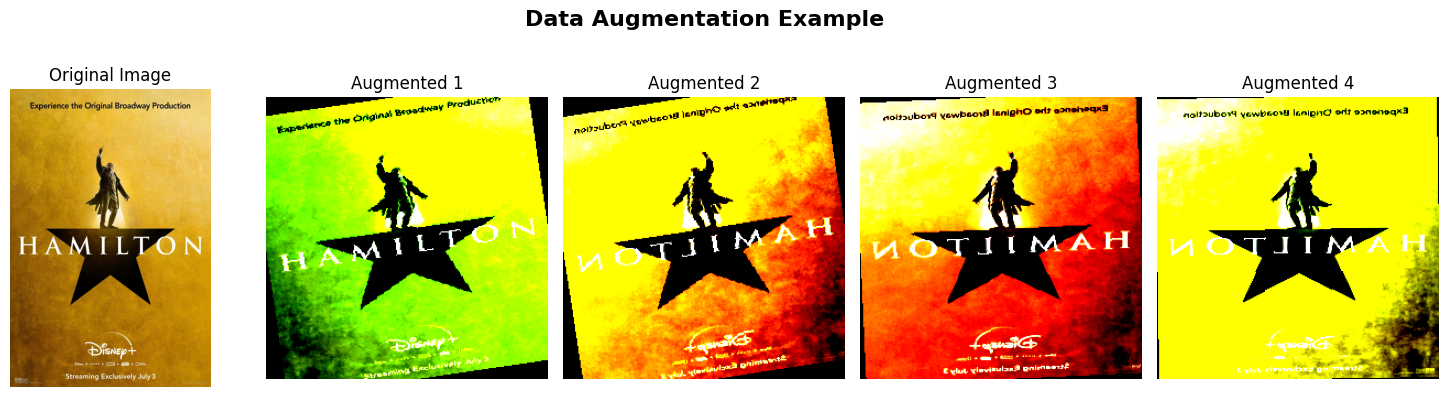

In [38]:
sample_img_filename = df_train['filename'].iloc[27]
sample_img_path = os.path.join(TRAIN_DIR, str(sample_img_filename))
original_image = Image.open(sample_img_path).convert('RGB')

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

for i in range(1, 5):
    augmented_image = train_tfm(original_image)
    axes[i].imshow(augmented_image.permute(1, 2, 0)) # Permute to HWC for matplotlib
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Example', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Step 6 — Dataset & DataLoaders

In [39]:
class MoviePosterDataset(Dataset):
    def __init__(self, df, img_dir, genre_cols, transform=None):
        self.df      = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.genres  = genre_cols
        self.tfm     = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = Image.open(os.path.join(self.img_dir,
                            str(row['filename']))).convert('RGB')
        if self.tfm: img = self.tfm(img)
        labels = torch.tensor(
            row[self.genres].values.astype(np.float32), dtype=torch.float32)
        return img, labels


train_ds = MoviePosterDataset(df_train, TRAIN_DIR, GENRE_COLS, train_tfm)
test_ds  = MoviePosterDataset(df_test,  TEST_DIR,  GENRE_COLS, test_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

x, y = next(iter(train_loader))
print(f'Images: {x.shape}  Labels: {y.shape}')

Images: torch.Size([32, 3, 256, 256])  Labels: torch.Size([32, 14])


## Step 7 — Model Factory (Simplified Linear Probe)

Architecture: `Pretrained backbone → BatchNorm1d → Dropout(p=0.5) → Linear(in_features, K)`

*Note: The massive 4-layer dense head from Fig. 7 of Unal et al. 2023 has been simplified to a regularized linear probe to prevent severe overfitting on our highly constrained 250-image dataset.*

In [40]:
def linear_head(in_f, K):
    """ Simplified head """
    return nn.Sequential(
        nn.BatchNorm1d(in_f),
        nn.Dropout(p=0.5),
        nn.Linear(in_f, K)
    )


def build_model(arch, K, freeze=True):
    a = arch.lower()

    if a == 'vgg16':
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        m.classifier = linear_head(m.classifier[0].in_features, K)

    elif a == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = linear_head(m.fc.in_features, K)

    elif a == 'densenet121':
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = linear_head(m.classifier.in_features, K)

    elif a == 'mobilenet':
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        m.classifier = linear_head(m.classifier[1].in_features, K)

    elif a == 'convnext':
        m = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        m.classifier[2] = linear_head(m.classifier[2].in_features, K)

    else:
        raise ValueError(f'Unknown arch: {arch}')

    if freeze:
        head_keywords = {'fc', 'classifier', 'AuxLogits'}
        for name, p in m.named_parameters():
            p.requires_grad = any(k in name for k in head_keywords)

    return m


# Quick sanity check
_m = build_model('resnet50', NUM_CLASSES).to(device)
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
print(f'Output shape: {_m(_x).shape}  (expected [2, {NUM_CLASSES}])')
del _m, _x
torch.cuda.empty_cache()

Output shape: torch.Size([2, 14])  (expected [2, 14])


## Step 8 — Training Loop

In [41]:
def pos_weight(df_tr, genre_cols, device):
    pos = torch.tensor(df_tr[genre_cols].sum().values, dtype=torch.float32)
    return ((len(df_tr) - pos) / pos.clamp(min=1)).to(device)


def train_epoch(model, loader, crit, opt, device):
    model.train(); total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = crit(model(x), y)
        loss.backward(); opt.step()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, crit, device):
    model.eval()
    total, probs_all, labels_all = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total += crit(logits, y).item() * x.size(0)
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        labels_all.append(y.int().cpu().numpy())
    P = np.vstack(probs_all)
    L = np.vstack(labels_all)
    hl = hamming_loss_fn(L, (P >= THRESHOLD).astype(int))
    return total / len(loader.dataset), hl, P, L


def train_arch(arch, df_tr, tr_loader, te_loader,
               K, genre_cols, device, epochs, lr, freeze):
    model  = build_model(arch, K, freeze).to(device)
    pw     = pos_weight(df_tr, genre_cols, device)
    crit   = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt    = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)

    hist = {'train_loss': [], 'val_loss': [], 'val_hl': []}
    best_hl, best_state = float('inf'), None

    tag = f"{arch.upper()} | freeze={freeze}"
    print(f'\n{"─"*58}')
    print(f'  {tag}')
    print(f'  {"Ep":>3} | {"TrainLoss":>9} | {"ValLoss":>8} | {"HammingLoss↓":>12}')
    print(f'  {"─"*46}')

    for ep in range(1, epochs + 1):
        tl = train_epoch(model, tr_loader, crit, opt, device)
        vl, hl, _, _ = eval_epoch(model, te_loader, crit, device)
        sched.step(vl)
        hist['train_loss'].append(tl)
        hist['val_loss'].append(vl)
        hist['val_hl'].append(hl)

        flag = ''
        if hl < best_hl:
            best_hl = hl
            best_state = copy.deepcopy(model.state_dict())
            flag = ' ★ best'

        print(f'  {ep:>3} | {tl:>9.4f} | {vl:>8.4f} | {hl:>12.4f}{flag}')

    save_p = os.path.join(SAVE_DIR, f'{arch}_freeze{freeze}.pth')
    torch.save(best_state, save_p)
    model.load_state_dict(best_state)
    print(f'  Best Hamming Loss = {best_hl:.4f}  saved → {save_p}')
    return model, hist, best_hl


print('Training functions defined ✓')

Training functions defined ✓


## Step 9 — Phase 1: Train All 5 Architectures (Frozen Backbone)

In [42]:
ARCHS = ['vgg16', 'resnet50','densenet121', 'mobilenet', 'convnext']

models_p1  = {}
history_p1 = {}
results_p1 = {}

for arch in ARCHS:
    m, h, hl = train_arch(
        arch, df_train, train_loader, test_loader,
        NUM_CLASSES, GENRE_COLS, device,
        epochs=NUM_EPOCHS, lr=LR, freeze=True
    )
    models_p1[arch]  = m
    history_p1[arch] = h
    results_p1[arch] = hl

print('\n✅ Phase 1 complete!')
for k, v in sorted(results_p1.items(), key=lambda x: x[1]):
    print(f'  {k:15s}  Hamming Loss = {v:.4f}')


──────────────────────────────────────────────────────────
  VGG16 | freeze=True
   Ep | TrainLoss |  ValLoss | HammingLoss↓
  ──────────────────────────────────────────────
    1 |    1.2253 |   1.0330 |       0.2343 ★ best
    2 |    0.7796 |   1.0874 |       0.2857
    3 |    0.5833 |   1.2378 |       0.3114
    4 |    0.4010 |   1.3408 |       0.2857
    5 |    0.3109 |   1.3248 |       0.2586
    6 |    0.2628 |   1.2911 |       0.2514
    7 |    0.1900 |   1.3257 |       0.2571
    8 |    0.1585 |   1.3969 |       0.2429
    9 |    0.1534 |   1.4457 |       0.2300 ★ best
   10 |    0.1136 |   1.4788 |       0.2243 ★ best
   11 |    0.1206 |   1.5317 |       0.2386
   12 |    0.1095 |   1.5929 |       0.2371
   13 |    0.1120 |   1.6672 |       0.2329
   14 |    0.0840 |   1.7397 |       0.2214 ★ best
   15 |    0.0800 |   1.7947 |       0.2143 ★ best
   16 |    0.0919 |   1.7452 |       0.2100 ★ best
   17 |    0.0752 |   1.7540 |       0.2043 ★ best
   18 |    0.0788 |   1.8064

## Step 10 — Phase 2: Fine-Tune Top-2 Models (Full Backbone)

In [43]:
top2 = [a for a, _ in sorted(results_p1.items(), key=lambda x: x[1])[:2]]
print(f'Fine-tuning: {top2}')

models_p2  = {}
history_p2 = {}
results_p2 = {}

for arch in top2:
    m, h, hl = train_arch(
        arch, df_train, train_loader, test_loader,
        NUM_CLASSES, GENRE_COLS, device,
        epochs=NUM_EPOCHS, lr=LR_FT, freeze=False
    )
    models_p2[arch]  = m
    history_p2[arch] = h
    results_p2[arch] = hl

print('\n✅ Phase 2 fine-tuning complete!')

Fine-tuning: ['resnet50', 'vgg16']

──────────────────────────────────────────────────────────
  RESNET50 | freeze=False
   Ep | TrainLoss |  ValLoss | HammingLoss↓
  ──────────────────────────────────────────────
    1 |    1.1197 |   0.9317 |       0.5229 ★ best
    2 |    1.1283 |   0.9372 |       0.4971 ★ best
    3 |    1.1020 |   0.9443 |       0.5043
    4 |    1.1027 |   0.9551 |       0.4800 ★ best
    5 |    1.0790 |   0.9634 |       0.4829
    6 |    1.0503 |   0.9708 |       0.4829
    7 |    1.0487 |   0.9739 |       0.4800
    8 |    1.0514 |   0.9692 |       0.4671 ★ best
    9 |    1.0282 |   0.9715 |       0.4714
   10 |    1.0296 |   0.9669 |       0.4771
   11 |    1.0101 |   0.9683 |       0.4757
   12 |    1.0053 |   0.9621 |       0.4686
   13 |    0.9832 |   0.9610 |       0.4686
   14 |    0.9985 |   0.9537 |       0.4571 ★ best
   15 |    0.9676 |   0.9502 |       0.4614
   16 |    0.9466 |   0.9482 |       0.4571
   17 |    0.9546 |   0.9460 |       0.4443 ★ b

## Step 11 — Training Curves (Loss + Hamming Loss)

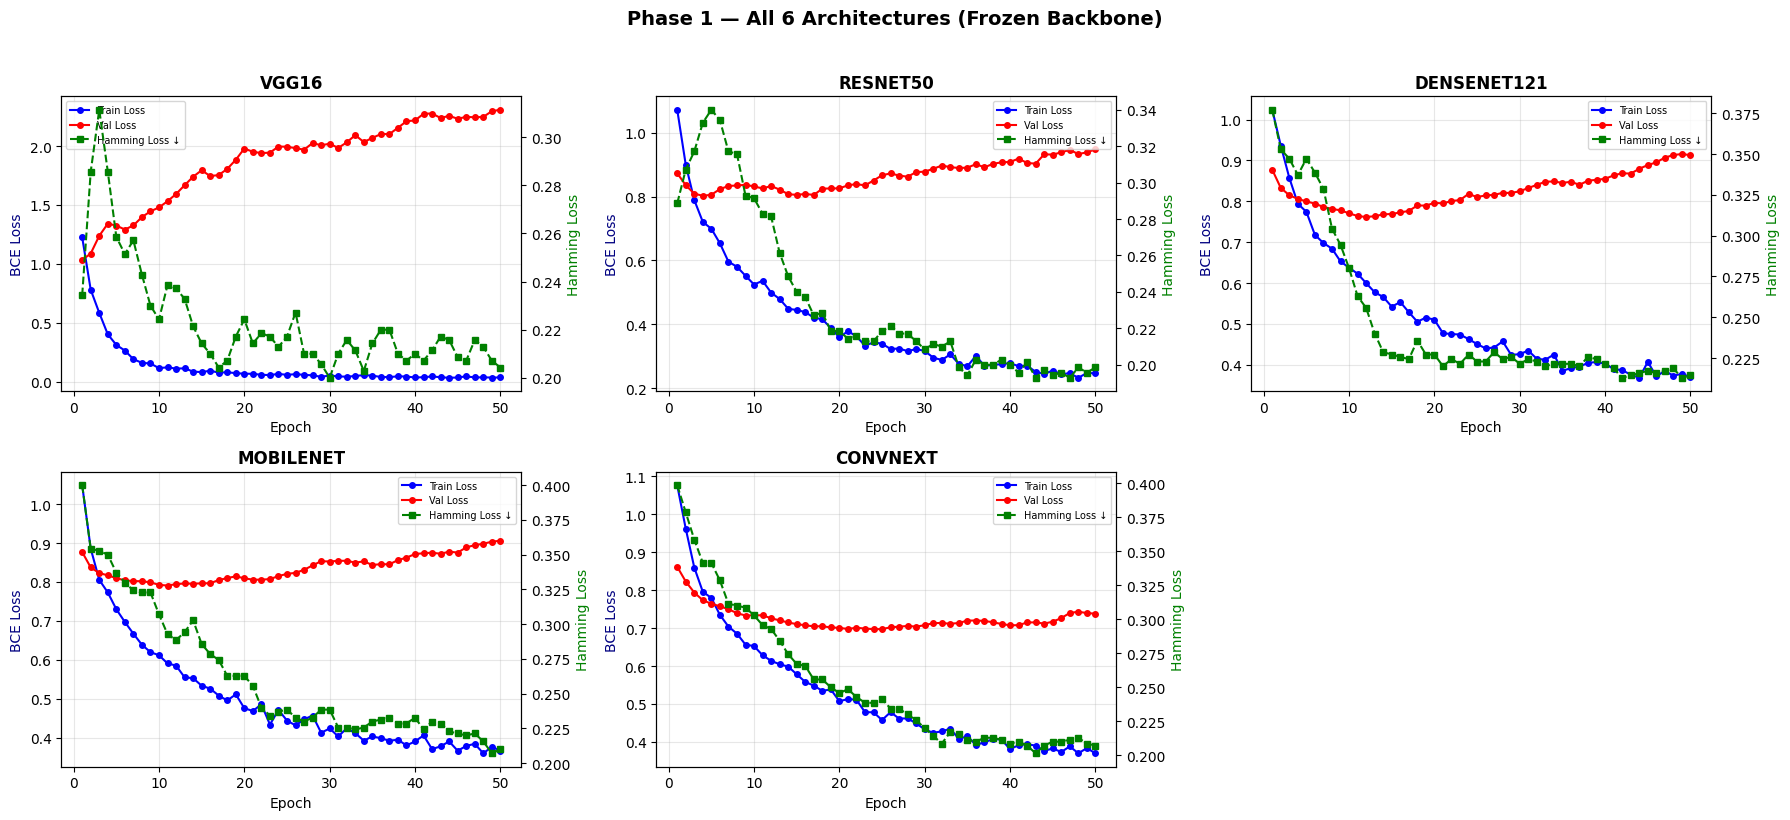

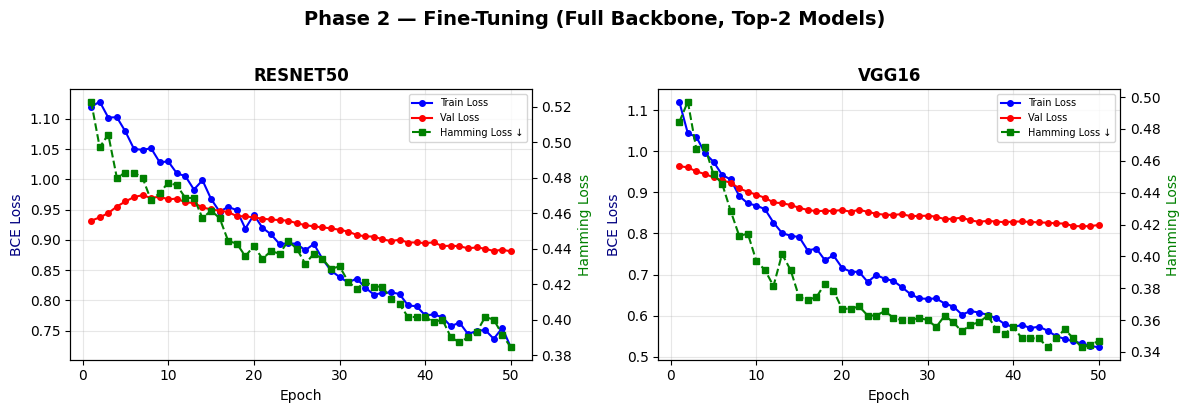

In [44]:
def plot_curves(hist_dict, title):
    n = len(hist_dict)
    c = min(n, 3); r = (n + c - 1) // c
    fig, axes = plt.subplots(r, c, figsize=(6*c, 4*r))
    axes = np.array(axes).flatten()

    for i, (arch, h) in enumerate(hist_dict.items()):
        ax  = axes[i]
        ax2 = ax.twinx()
        eps = range(1, len(h['train_loss'])+1)

        ax.plot(eps, h['train_loss'], 'b-o', ms=4, label='Train Loss')
        ax.plot(eps, h['val_loss'],   'r-o', ms=4, label='Val Loss')
        ax2.plot(eps, h['val_hl'],    'g--s', ms=4, label='Hamming Loss ↓')

        ax.set_title(arch.upper(), fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('BCE Loss', color='navy')
        ax2.set_ylabel('Hamming Loss', color='green')
        l1, lb1 = ax.get_legend_handles_labels()
        l2, lb2 = ax2.get_legend_handles_labels()
        ax.legend(l1+l2, lb1+lb2, fontsize=7)
        ax.grid(alpha=0.3)

    for j in range(i+1, len(axes)): axes[j].axis('off')
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()


plot_curves(history_p1, 'Phase 1 — All 6 Architectures (Frozen Backbone)')
if history_p2:
    plot_curves(history_p2, 'Phase 2 — Fine-Tuning (Full Backbone, Top-2 Models)')

## Step 12 — Full Evaluation on Test Set (All 6 Models)

In [45]:
eval_crit = nn.BCEWithLogitsLoss()
rows = []

# Phase 1 models
for arch in ARCHS:
    _, _, P, L = eval_epoch(models_p1[arch], test_loader, eval_crit, device)
    m, _, _ = compute_all_metrics(L, P, THRESHOLD, TOP_K)
    rows.append({
        'Model'          : arch.upper(),
        'Phase'          : 'Frozen',
        'Hamming (τ=0.5)': round(m['hamming_thr'],   4),
        'Hamming (Top-4)': round(m['hamming_topk'],  4),
        'Accuracy'       : round(m['accuracy_thr'],  4),
        'Precision'      : round(m['precision_thr'], 4),
        'F1-Score'       : round(m['f1_thr'],        4),
    })

# Phase 2 fine-tuned models
for arch in top2:
    _, _, P, L = eval_epoch(models_p2[arch], test_loader, eval_crit, device)
    m, _, _ = compute_all_metrics(L, P, THRESHOLD, TOP_K)
    rows.append({
        'Model'          : arch.upper() + ' (FT)',
        'Phase'          : 'Fine-tuned',
        'Hamming (τ=0.5)': round(m['hamming_thr'],   4),
        'Hamming (Top-4)': round(m['hamming_topk'],  4),
        'Accuracy'       : round(m['accuracy_thr'],  4),
        'Precision'      : round(m['precision_thr'], 4),
        'F1-Score'       : round(m['f1_thr'],        4),
    })

df_res = pd.DataFrame(rows)
print(df_res.to_string(index=False))

        Model      Phase  Hamming (τ=0.5)  Hamming (Top-4)  Accuracy  Precision  F1-Score
        VGG16     Frozen           0.2000           0.2043      0.12     0.6491    0.6084
     RESNET50     Frozen           0.1929           0.1757      0.04     0.6456    0.6423
  DENSENET121     Frozen           0.2129           0.2043      0.10     0.6232    0.6183
    MOBILENET     Frozen           0.2071           0.1929      0.04     0.6512    0.6229
     CONVNEXT     Frozen           0.2014           0.1900      0.02     0.6436    0.6369
RESNET50 (FT) Fine-tuned           0.3843           0.3271      0.00     0.3804    0.4550
   VGG16 (FT) Fine-tuned           0.3429           0.2700      0.00     0.4279    0.5204


## Step 13 — Comparison Charts (Matching Paper Style)

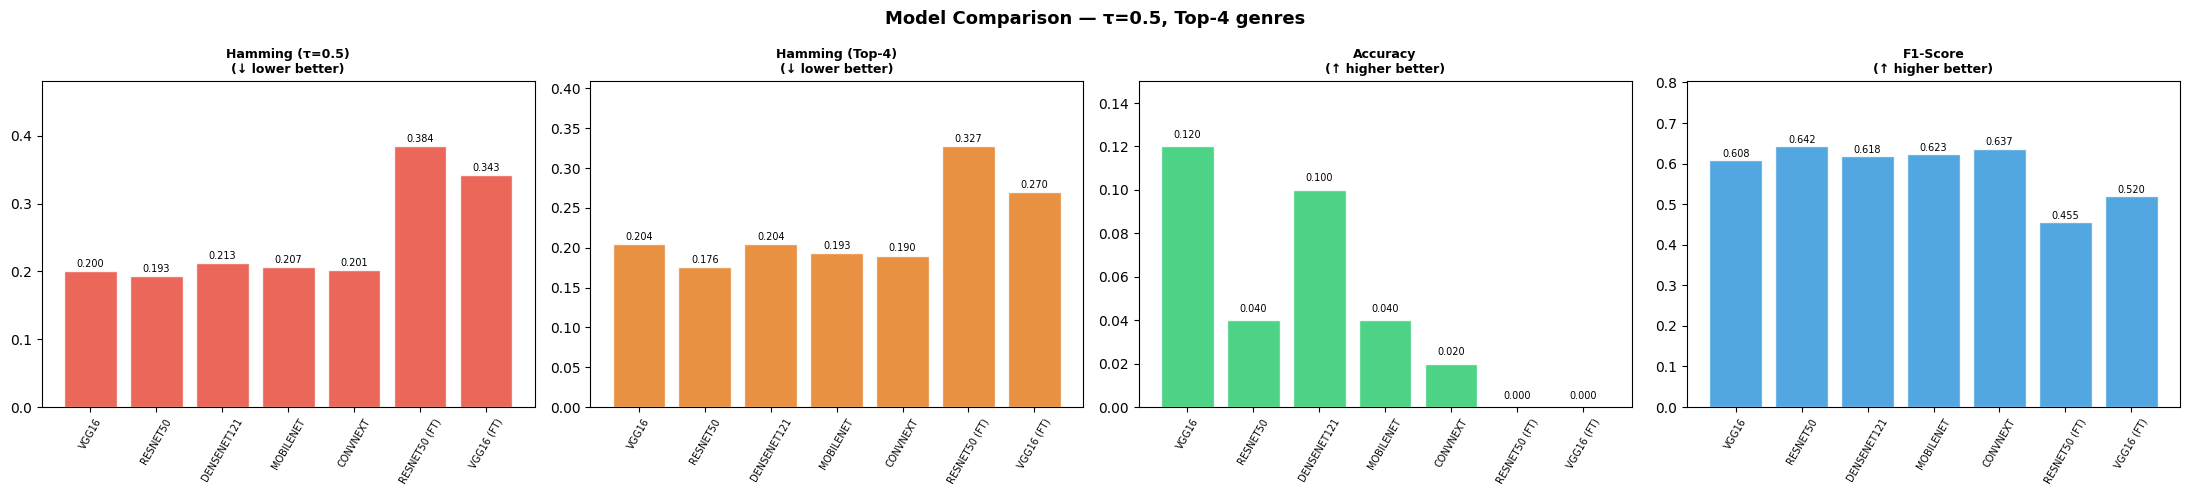

In [46]:
metrics_to_plot = [
    ('Hamming (τ=0.5)', '#e74c3c', '↓ lower better'),
    ('Hamming (Top-4)', '#e67e22', '↓ lower better'),
    ('Accuracy',        '#2ecc71', '↑ higher better'),
    ('F1-Score',        '#3498db', '↑ higher better'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (metric, color, note) in zip(axes, metrics_to_plot):
    vals   = df_res[metric].astype(float)
    labels = df_res['Model']
    bars   = ax.bar(labels, vals, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{metric}\n({note})', fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', rotation=60, labelsize=7)

    # --- Start of fix ---
    max_val = vals.max()
    if np.isnan(max_val) or max_val <= 0.001:
        # If all values are NaN or effectively zero, set y-limit to 0-1
        # This prevents ValueError for NaN and provides a visible range for all 0s.
        upper_limit = 1.0
    else:
        upper_limit = max_val * 1.25

    ax.set_ylim(0, upper_limit)
    # --- End of fix ---

    for bar, v in zip(bars, vals):
        # Only add text labels if the value is not NaN
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)

fig.suptitle(f'Model Comparison — τ={THRESHOLD}, Top-{TOP_K} genres',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Step 14 — Single Poster Prediction (Top-4 + τ=0.5)

Best model: RESNET50


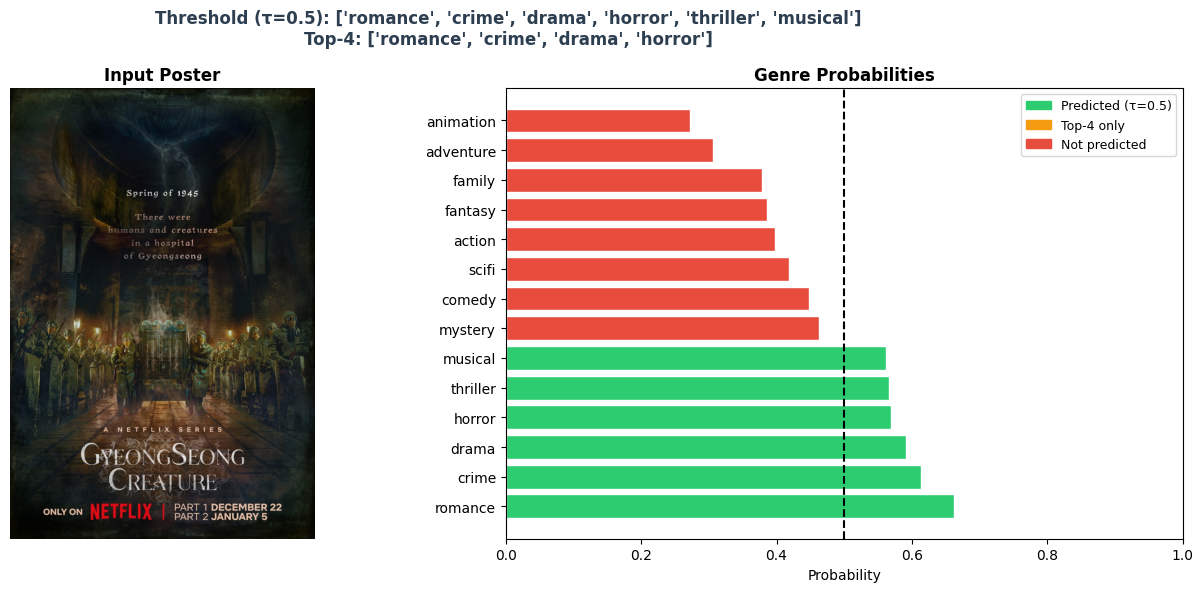

In [47]:
def predict_poster(img_path, model, genre_cols, tfm, device,
                   threshold=THRESHOLD, top_k=TOP_K):
    image  = Image.open(img_path).convert('RGB')
    tensor = tfm(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(tensor)).squeeze().cpu().numpy()

    # Sort descending
    order  = np.argsort(probs)[::-1]
    g_sort = [genre_cols[i] for i in order]
    p_sort = probs[order]

    pred_thr  = [g for g, p in zip(g_sort, p_sort) if p >= threshold]
    pred_topk = g_sort[:top_k]

    # Bar colors
    colors = []
    for g, p in zip(g_sort, p_sort):
        if p >= threshold:    colors.append('#2ecc71')   # green
        elif g in pred_topk:  colors.append('#f39c12')   # orange
        else:                 colors.append('#e74c3c')   # red

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.imshow(image); ax1.axis('off')
    ax1.set_title('Input Poster', fontweight='bold')

    ax2.barh(g_sort, p_sort, color=colors, edgecolor='white')
    ax2.axvline(threshold, color='black', linestyle='--', lw=1.5,
                label=f'τ = {threshold}')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Probability')
    ax2.set_title('Genre Probabilities', fontweight='bold')

    patches = [
        mpatches.Patch(color='#2ecc71', label=f'Predicted (τ={threshold})'),
        mpatches.Patch(color='#f39c12', label=f'Top-{top_k} only'),
        mpatches.Patch(color='#e74c3c', label='Not predicted'),
    ]
    ax2.legend(handles=patches, fontsize=9)

    fig.suptitle(
        f'Threshold (τ={threshold}): {pred_thr}\nTop-{top_k}: {pred_topk}',
        fontsize=12, fontweight='bold', color='#2c3e50'
    )
    plt.tight_layout(); plt.show()

    return {'threshold': pred_thr, 'top_k': pred_topk,
            'probs': dict(zip(g_sort, p_sort))}


# ── Use best model for prediction ─────────────────────────────────────────────
best_arch  = df_res.loc[df_res['Hamming (τ=0.5)'].idxmin(), 'Model']
best_key   = best_arch.lower().replace(' (ft)', '')
best_model = (models_p2.get(best_key) or models_p1.get(best_key))
print(f'Best model: {best_arch}')

# Predict on first test image
sample_path = os.path.join(TEST_DIR, str(df_test['filename'].iloc[3]))
result = predict_poster(sample_path, best_model, GENRE_COLS,
                        test_tfm, device)

## Step 15 — Final Summary Table

In [48]:
print('═'*80)
print(f'  FINAL RESULTS  |  τ = {THRESHOLD}  |  Top-{TOP_K} Genres  |  Hamming Loss (↓ better)')
print('═'*80)
print(df_res.to_string(index=False))
print('═'*80)

best_row = df_res.loc[df_res['Hamming (τ=0.5)'].idxmin()]
print(f'\n  🏆 Best Model : {best_row["Model"]}')
print(f'     Hamming Loss (τ=0.5) = {best_row["Hamming (τ=0.5)"]}')
print(f'     Hamming Loss (Top-4) = {best_row["Hamming (Top-4)"]}')
print(f'     F1-Score             = {best_row["F1-Score"]}')
print('═'*80)

# Save CSV
csv_path = os.path.join(SAVE_DIR, 'results_all_models.csv')
df_res.to_csv(csv_path, index=False)
print(f'Results saved: {csv_path}')

════════════════════════════════════════════════════════════════════════════════
  FINAL RESULTS  |  τ = 0.5  |  Top-4 Genres  |  Hamming Loss (↓ better)
════════════════════════════════════════════════════════════════════════════════
        Model      Phase  Hamming (τ=0.5)  Hamming (Top-4)  Accuracy  Precision  F1-Score
        VGG16     Frozen           0.2000           0.2043      0.12     0.6491    0.6084
     RESNET50     Frozen           0.1929           0.1757      0.04     0.6456    0.6423
  DENSENET121     Frozen           0.2129           0.2043      0.10     0.6232    0.6183
    MOBILENET     Frozen           0.2071           0.1929      0.04     0.6512    0.6229
     CONVNEXT     Frozen           0.2014           0.1900      0.02     0.6436    0.6369
RESNET50 (FT) Fine-tuned           0.3843           0.3271      0.00     0.3804    0.4550
   VGG16 (FT) Fine-tuned           0.3429           0.2700      0.00     0.4279    0.5204
═════════════════════════════════════════════